# Task 1
We will be importing the news sample with pandas, where we can use the read_csv function to get the sample into a data frame

In [ ]:
import pandas as pd
import swifter
import re
from rich.progress import track
import nltk
import Stemmer
from matplotlib import pyplot as plt
raw_data = pd.read_csv('../Group_project/news_sample.csv', dtype = 'string')

['hate', 'conspiracy', 'reliable', 'fake', 'bias', 'unknown', 'junksci', 'political', 'clickbait', 'unreliable', <NA>]


Having imported the data set we can create a function that cleans the data, here we can use the pandas apply() function, so the only function we need is a function that given a series cleans the data to the required specification. Additionally i have removed the comma at the beginning of the sample to remove the unnamed row

In [23]:
EMAIL_REGEX = re.compile(r'\\w+\\w+@\\w+\\.\\w+')
URL_REGEX1 = re.compile(r'https?:((//)|(\\\\))+[^, ]+')
URL_REGEX2 = re.compile(r'www\\.[^, ]+')
NUM_REGEX = re.compile(r'[0-9]+')
DATE_REGEX = re.compile(r'<NUM>-<NUM>-<NUM>.?<NUM>:<NUM>:<NUM>.?<NUM>')

def clean_string(text, **kwargs):
    text = str(text)

    text = text.lower().replace('\n', '').strip()
    
    text = EMAIL_REGEX.sub('<EMAIL>', text)
    text = URL_REGEX1.sub('<URL>', text)
    text = URL_REGEX2.sub('<URL>', text)
    text = NUM_REGEX.sub('<NUM>', text)
    text = DATE_REGEX.sub('<DATE>', text)
    
    return text

def clean_df(df):
    c_df = pd.DataFrame({})
    total = 0
    for i in track(df.columns, 'processing...'):
        c_df[i] = df[i].swifter.progress_bar(False).apply(clean_string)
        total += 1
    return c_df

cleaned_data = clean_df(raw_data)
print(cleaned_data)


Output()

        id                domain        type    url  \
0    <NUM>               awm.com  unreliable  <URL>   
1    <NUM>     beforeitsnews.com        fake  <URL>   
2    <NUM>           cnnnext.com  unreliable  <URL>   
3    <NUM>               awm.com  unreliable  <URL>   
4    <NUM>  bipartisanreport.com   clickbait  <URL>   
..     ...                   ...         ...    ...   
245  <NUM>     beforeitsnews.com        fake  <URL>   
246  <NUM>     beforeitsnews.com        fake  <URL>   
247  <NUM>       www.newsmax.com        <na>  <URL>   
248  <NUM>       www.newsmax.com        <na>  <URL>   
249  <NUM>       www.newsmax.com        <na>  <URL>   

                                               content scraped_at inserted_at  \
0    sometimes the power of christmas will make you...     <DATE>      <DATE>   
1    awakening of <NUM> strands of dna – “reconnect...     <DATE>      <DATE>   
2    never hike alone: a friday the <NUM>th fan fil...     <DATE>      <DATE>   
3    when a rar

We have now cleaned the data and we can move on to tokenizing the text

In [24]:
def tokenize_df(df):
    tk_df = pd.DataFrame({})
    total = 0
    for i in track(df.columns, 'processing...'):
        tk_df[i] = df[i].swifter.progress_bar(False).apply(
            lambda x, **kwargs: nltk.word_tokenize(str(x)))
        total += 1
    return tk_df

tokenized = tokenize_df(cleaned_data)
print(tokenized)

Output()

              id                  domain          type          url  \
0    [<, NUM, >]               [awm.com]  [unreliable]  [<, URL, >]   
1    [<, NUM, >]     [beforeitsnews.com]        [fake]  [<, URL, >]   
2    [<, NUM, >]           [cnnnext.com]  [unreliable]  [<, URL, >]   
3    [<, NUM, >]               [awm.com]  [unreliable]  [<, URL, >]   
4    [<, NUM, >]  [bipartisanreport.com]   [clickbait]  [<, URL, >]   
..           ...                     ...           ...          ...   
245  [<, NUM, >]     [beforeitsnews.com]        [fake]  [<, URL, >]   
246  [<, NUM, >]     [beforeitsnews.com]        [fake]  [<, URL, >]   
247  [<, NUM, >]       [www.newsmax.com]    [<, na, >]  [<, URL, >]   
248  [<, NUM, >]       [www.newsmax.com]    [<, na, >]  [<, URL, >]   
249  [<, NUM, >]       [www.newsmax.com]    [<, na, >]  [<, URL, >]   

                                               content    scraped_at  \
0    [sometimes, the, power, of, christmas, will, m...  [<, DATE, >]   
1  

In [25]:
stop_words = frozenset([word for word in (pd.read_table('englishST.txt'))['words']])

def remove_stop_words(df):
    st_df = pd.DataFrame({})
    total = 0
    for i in track(df.columns, 'processing...'):
        st_df[i] = df[i].swifter.progress_bar(False).apply(
            lambda x, **kwargs: [word for word in x if word not in stop_words]
        )
        total += 1
    return st_df

no_stop_words = remove_stop_words(tokenized)
print(no_stop_words)

Output()

              id                  domain          type          url  \
0    [<, NUM, >]               [awm.com]  [unreliable]  [<, URL, >]   
1    [<, NUM, >]     [beforeitsnews.com]        [fake]  [<, URL, >]   
2    [<, NUM, >]           [cnnnext.com]  [unreliable]  [<, URL, >]   
3    [<, NUM, >]               [awm.com]  [unreliable]  [<, URL, >]   
4    [<, NUM, >]  [bipartisanreport.com]   [clickbait]  [<, URL, >]   
..           ...                     ...           ...          ...   
245  [<, NUM, >]     [beforeitsnews.com]        [fake]  [<, URL, >]   
246  [<, NUM, >]     [beforeitsnews.com]        [fake]  [<, URL, >]   
247  [<, NUM, >]       [www.newsmax.com]    [<, na, >]  [<, URL, >]   
248  [<, NUM, >]       [www.newsmax.com]    [<, na, >]  [<, URL, >]   
249  [<, NUM, >]       [www.newsmax.com]    [<, na, >]  [<, URL, >]   

                                               content    scraped_at  \
0    [power, christmas, make, wild, wonderful, thin...  [<, DATE, >]   
1  

In [26]:
def find_vocabulary(df):
    word_pattern = re.compile(r"[a-z]+'?[a-z]*")
    w = {}
    total = 0
    for col in track(df.columns, description='Processing...'):
        for word_list in df[col]:
            for k in word_list:
                if k in w:
                    w[k] += 1
                elif word_pattern.fullmatch(k):
                    w[k] = 1
        total += 1
                
    return w

vocabulary_st = find_vocabulary(tokenized)
print(len(vocabulary_st))
vocabulary_no_st = find_vocabulary(no_stop_words)
print(len(vocabulary_no_st))
print(len(vocabulary_st) - len(vocabulary_no_st))

Output()

Output()

15815


15332
483


In [27]:
w_stemmer = Stemmer.Stemmer('english')

def stem_words(df):
    st_df = pd.DataFrame({})
    total = 0
    for i in track(df.columns, 'processing...'):
        st_df[i] = df[i].swifter.progress_bar(False).apply(
            lambda x, **kwargs: w_stemmer.stemWords(x)
        )
        total += 1
    return st_df

stemmed = stem_words(no_stop_words)

vocabulary_stem = find_vocabulary(stemmed)
print(len(vocabulary_stem))
print(len(vocabulary_no_st) - len(vocabulary_stem))

Output()

Output()

10282
5050


In [29]:
full_dataset = pd.read_csv('../Group_project/995,000_rows.csv', dtype = 'string')

In [9]:
def process_article(text, **kwargs):
    local_stemmer = Stemmer.Stemmer('english')
    text = str(text).lower().replace('\n', '').strip()
    text = EMAIL_REGEX.sub('<EMAIL>', text)
    text = URL_REGEX1.sub('<URL>', text)
    text = URL_REGEX2.sub('<URL>', text)
    text = NUM_REGEX.sub('<NUM>', text)
    text = DATE_REGEX.sub('<DATE>', text)
    
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [w for w in tokens if w not in stop_words]
    return local_stemmer.stemWords(filtered_tokens)

def pre_processing(df):
    processed_df = pd.DataFrame()
    for col in track(df.columns, description='Processing...'):
        processed_df[col] = df[col].swifter.progress_bar(False).apply(process_article)
    return processed_df

pre_processed_df = pre_processing(full_dataset)
print(pre_processed_df)

Output()

         Unnamed: 0                         id  \
0       [<, NUM, >]  [<, NUM, >, ., <, NUM, >]   
1       [<, NUM, >]  [<, NUM, >, ., <, NUM, >]   
2       [<, NUM, >]  [<, NUM, >, ., <, NUM, >]   
3       [<, NUM, >]  [<, NUM, >, ., <, NUM, >]   
4       [<, NUM, >]  [<, NUM, >, ., <, NUM, >]   
...             ...                        ...   
994995  [<, NUM, >]                [<, NUM, >]   
994996  [<, NUM, >]                [<, NUM, >]   
994997  [<, NUM, >]                [<, NUM, >]   
994998  [<, NUM, >]                [<, NUM, >]   
994999  [<, NUM, >]                [<, NUM, >]   

                                domain          type          url  \
0                 [nationalreview.com]       [polit]  [<, URL, >]   
1                  [beforeitsnews.com]        [fake]  [<, URL, >]   
2                   [dailycurrant.com]       [satir]  [<, URL, >]   
3                        [nytimes.com]     [reliabl]  [<, URL, >]   
4                [infiniteunknown.net]  [conspiraci]  

In [10]:
full_vocabulary = find_vocabulary(pre_processed_df)
print(len(full_vocabulary))

Output()

1386873


In [11]:
vocabulary_df = pd.DataFrame(list(full_vocabulary.items()), columns=['word', 'Amount'])
vocabulary_df = vocabulary_df.sort_values(by = 'Amount', ascending = False, ignore_index=True)
vocabulary_df.to_csv('vocabulary_995000.csv')
print(vocabulary_df)

                word   Amount
0                 na  4612324
1              state  1015838
2               time   980130
3               year   912774
4              peopl   891321
...              ...      ...
1386868      escolhi        1
1386869  sigaintevyh        1
1386870     preenchi        1
1386871        pular        1
1386872      strugil        1

[1386873 rows x 2 columns]


In [12]:
training_set = pre_processed_df.sample(frac = 0.8)
rest = pre_processed_df.drop(training_set.index)
validation_set = rest.sample(frac = 0.5)
test_set = rest.drop(validation_set.index)

In [13]:
training_set.to_csv('training_set.csv')
validation_set.to_csv('validation_set.csv')
test_set.to_csv('test_set.csv')

# non trivial observations

In [14]:
fake_df = pre_processed_df[pre_processed_df['type'].apply(lambda x: x == ['fake'])]

reliable_df = pre_processed_df[pre_processed_df['type'].apply(lambda x: x == ['reliabl'])]

remaining_df = pre_processed_df[pre_processed_df['type'].apply(lambda x: x != ['reliabl'] and x != ['fake'])]


#Fake articles:
print('Percentage of articles labeled "fake":', len(fake_df)/len(pre_processed_df)*100)

#Reliable articles:
print('Percentage of articles labeled "reliable":', len(reliable_df)/len(pre_processed_df)*100)

#Remaining articles:
print('Percentage of remaining articles:', ((len(pre_processed_df)-len(fake_df)-len(reliable_df))/len(pre_processed_df))*100)




Percentage of articles labeled "fake": 10.541005025125628
Percentage of articles labeled "reliable": 21.966231155778896
Percentage of remaining articles: 67.49276381909549


Most frequent words in fake vs reliable articles.

In [15]:
reliable_voc = pd.DataFrame(list(find_vocabulary(reliable_df).items()), columns=['Word', 'Amount'])
reliable_voc = reliable_voc.sort_values(by = 'Amount', ascending = False, ignore_index=True)
print(reliable_voc)

fake_voc = pd.DataFrame(list(find_vocabulary(fake_df).items()), columns=['Word', 'Amount'])
fake_voc = fake_voc.sort_values(by = 'Amount', ascending = False, ignore_index=True)
print(fake_voc)

Output()

Output()

            Word  Amount
0             na  832962
1           time  337281
2           york  285051
3           year  270120
4        continu  244762
...          ...     ...
399898  dambulla       1
399899  schiefel       1
399900    raefer       1
399901     panyu       1
399902      icka       1

[399903 rows x 2 columns]


               Word  Amount
0                na  551098
1              fake  108191
2              news  104941
3              time   92487
4             peopl   90510
...             ...     ...
313997   tocomplain       1
313998      andzach       1
313999     jensengo       1
314000  creightonin       1
314001       newlun       1

[314002 rows x 2 columns]


<Axes: xlabel='Word'>

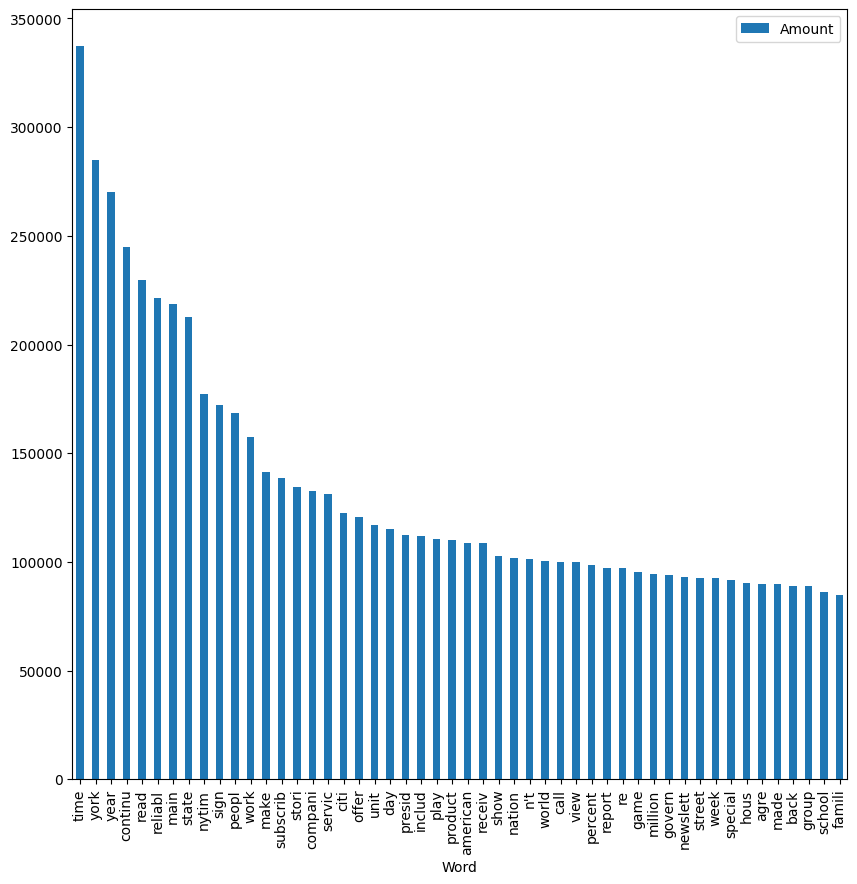

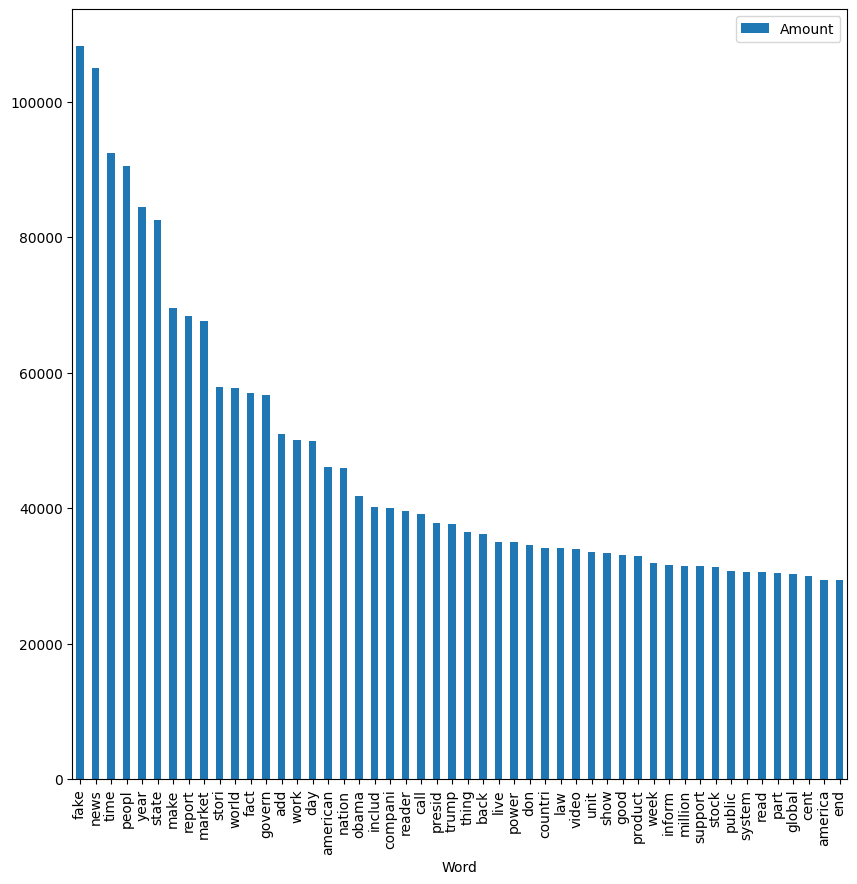

In [16]:
reliable_voc.loc[1:50].plot(x = 'Word', y = 'Amount',
        kind = 'bar', figsize = (10, 10))

fake_voc.loc[1:50].plot(x = 'Word', y = 'Amount',
        kind = 'bar', figsize = (10, 10))

Analysing domains

In [17]:
valid_types = ['fake', 'satire', 'bias', 'conspiracy', 'state', 'junksci', 'hate', 'clickbait', 'unreliable', 'political', 'reliable']

def find_domains(df):
    domain_dict = {}
    for i in track(range(len(df))):
        if df.loc[i]['domain'] not in domain_dict.keys():
            domain_dict[df.loc[i]['domain']] = [df.loc[i]['type']]
        elif df.loc[i]['type'] not in domain_dict[df.loc[i]['domain']]:
            domain_dict[df.loc[i]['domain']].append(df.loc[i]['type'])
    domain_df = pd.DataFrame(list(domain_dict.items()), columns=['Domain', 'Types'])
    domain_df = domain_df.sort_values(by = 'Types', key=lambda col: col.map(len), ascending = False, ignore_index=True)
    return domain_df

print(find_domains(full_dataset))

Output()

                  Domain         Types
0     nationalreview.com   [political]
1                ijr.com   [political]
2    thevalleyreport.com      [satire]
3     uspoliticslive.com        [fake]
4       islamicanews.com      [satire]
..                   ...           ...
679   randpaulreview.com     [unknown]
680     thegoldwater.com     [unknown]
681       henrymakow.com  [conspiracy]
682    www.investing.com    [reliable]
683     newsmagazine.com        [fake]

[684 rows x 2 columns]
